## 1. Постановка задачи


В данном проекте вы решите настоящую бизнес-задачу в области маркетинга. Вам предстоит произвести сегментацию клиентов на основе их покупательской способности, частоты совершения заказов и срока давности последнего заказа, а также определить оптимальную стратегию взаимодействия с ними.
<center> <img src=https://salesupnow.ru/storage/app/media/pipeople.png align="right" width="300"/> </center>

Маркетинг — неотъемлемая часть любого бизнеса. Для повышения прибыли компании важно понимать своего клиента, его пожелания и предпочтения. С появлением электронной коммерции, или онлайн-продаж, стало намного проще собирать данные о клиентах, анализировать их, находить закономерности и реализовывать маркетинговые кампании.

Большинство интернет-магазинов используют инструменты веб-аналитики, чтобы отслеживать просмотры страниц, количество и поведение посетителей и коэффициент отказов. Но отчёта из Google Analytics или аналогичной системы может быть недостаточно для полного понимания того, как клиенты взаимодействуют с сайтом. Компаниям важно иметь возможность быстро и точно реагировать на перемены в поведении клиентов, создавая инструменты, которые обнаруживают эти изменения практически в режиме реального времени.

Машинное обучение помогает поисковой системе анализировать огромное количество данных о посетителях платформы, узнавать модели поведения профессиональных покупателей, определять категорию клиентов (например, лояльные/перспективные/новички/спящие/ушедшие) и выбирать правильную стратегию взаимодействия с ними.

Стоит также отметить, что компании, использующие машинное обучение на своих платформах электронной коммерции, могут постоянно повышать эффективность бизнес-процессов: настраивать товарную выборку персонально для каждого покупателя и предлагать выгодную цену в соответствии с бюджетом клиента и т. д. Эта задача относится к категории построения рекомендательных систем, речь о которых пойдёт в следующем разделе нашего курса.

Как правило, наборы данных для электронной коммерции являются частной собственностью и, следовательно, их трудно найти среди общедоступных данных. 

**Бизнес-задача:** произвести сегментацию существующих клиентов, проинтерпретировать эти сегменты и определить стратегию взаимодействия с ними.

**Техническая задача для вас как для специалиста в Data Science:** построить модель кластеризации клиентов на основе их покупательской способности, частоты заказов и срока давности последней покупки, определить профиль каждого из кластеров.

**Основные цели проекта:**
1. Произвести предобработку набора данных.
2. Провести разведывательный анализ данных и выявить основные закономерности.
3. Сформировать категории товаров и клиентов. 
4. Построить несколько моделей машинного обучения, решающих задачу кластеризации клиентов, определить количество кластеров и проинтерпретировать их.
5. Спроектировать процесс предсказания категории интересов клиента и протестировать вашу модель на новых клиентах.



## 2. Знакомство с данными. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots

from sklearn import mixture
from sklearn import manifold
from sklearn import pipeline
from sklearn import preprocessing
from sklearn import cluster
from sklearn import metrics
from sklearn import model_selection
from sklearn import decomposition
from sklearn import ensemble
import warnings 

from IPython.display import display, HTML

warnings.filterwarnings("ignore")

plt.rcParams["patch.force_edgecolor"] = True

Первым делом необходимо понять, с какими данными нам предстоит работать, и произвести базовую предобработку данных, переведя признаки в необходимые для дальнейшей работы форматы.


Для начала давайте познакомимся с нашими данными:

In [2]:
data = pd.read_csv(
    "customer_segmentation_project.csv", 
    encoding="ISO-8859-1", 
    dtype={'CustomerID': str,'InvoiceID': str}
)
print('Data shape: {}'.format(data.shape))
data.head(5)

Data shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom


Итак, у нас есть данные о более чем полумиллионе транзакций. Каждая из них описывается следующими признаками:

* InvoiceNo — номер счёта-фактуры (уникальный номинальный шестизначный номер, присваиваемый каждой транзакции; буква "C" в начале кода указывает на отмену транзакции);
* Stock Code — код товара (уникальное пятизначное целое число, присваиваемое каждому отдельному товару);
* Description — название товара;
* Quantity — количество каждого товара за транзакцию; 
* InvoiceDate — дата и время выставления счёта/проведения транзакции;
* UnitPrice — цена за единицу товара в фунтах стерлингов;
* CustomerID — идентификатор клиента (уникальный пятизначный номер, однозначно присваиваемый каждому клиенту);
* Country — название страны, в которой проживает клиент.

Проведём анализ структуры таблицы.


### Задание 2.1
Сколько столбцов в данных кодируются числовыми типами (int/float)?

In [3]:
# Выводим информацию о DataFrame
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  object 
 7   Country      541909 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 33.1+ MB


### Задание 2.2
Выберите столбцы, в которых есть хотя бы один пропуск:
* InvoiceNo
* StockCode
* Description
* CustomerID
* Country 

In [4]:
# Проверяем наличие пропусков в каждом столбце
missing_values = data.isnull().sum()

# Выводим только те столбцы, где есть пропуски
columns_with_missing = missing_values[missing_values > 0]
print(columns_with_missing)

Description      1454
CustomerID     135080
dtype: int64


### Задание 2.3
Судя по описанию задачи, нам должны были предоставить данные за годовой период — проверим, так ли это.

Преобразуйте столбец InvoiceDate в формат datetime.
Укажите, за какой промежуток времени представлены данные:

* 2010-12-01 to 2011-12-09
* 2011-12-01 to 2012-12-09
* 2010-01-01 to 2011-01-09
* 2020-12-01 to 2021-12-09


In [5]:
# Преобразуем InvoiceDate в datetime
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

# Находим минимальную и максимальную дату
min_date = data['InvoiceDate'].min()
max_date = data['InvoiceDate'].max()

# Вычисляем разницу
date_range = max_date - min_date
print(f"Данные охватывают период с {min_date.strftime('%d.%m.%Y')} по {max_date.strftime('%d.%m.%Y')}")

Данные охватывают период с 01.12.2010 по 09.12.2011


### Задание 2.4

1) Каково максимальное количество товаров в заказе (Quantity)? Ответ приведите в виде целого числа.

2) Каково минимальное количество товаров в заказе (Quantity)? Ответ приведите в виде целого числа.

3) Сколько, согласно данным, стоит самый дешёвый товар (за исключением товаров с отрицательной стоимостью)?

In [6]:
# Получаем описательные статистики для числовых столбцов
print(data[['Quantity', 'UnitPrice']].describe())

# Находим стоимость самого дешёвого товара (за исключением товаров с отрицательной стоимостью)
min_positive_price = data[data['UnitPrice'] >= 0]['UnitPrice'].min()
print(f"Стоимость самого дешёвого товара: {min_positive_price}")

            Quantity      UnitPrice
count  541909.000000  541909.000000
mean        9.552250       4.611114
std       218.081158      96.759853
min    -80995.000000  -11062.060000
25%         1.000000       1.250000
50%         3.000000       2.080000
75%        10.000000       4.130000
max     80995.000000   38970.000000
Стоимость самого дешёвого товара: 0.0


### Задание 2.5
1) Сколько уникальных клиентов покупали товары за период выгрузки датасета?

2) Сколько уникальных стран содержится в столбце Country (исключая специальный код 'Unspecified', обозначающий неопределенную страну)?

3) Укажите идентификатор самого популярного товара (StockCode):
* 85123A
* 64812
* 51242
* 24151B


In [7]:
# Сколько уникальных клиентов покупали товары за период выгрузки датасета
unique_customers = data['CustomerID'].nunique()
print(f"Количество уникальных клиентов: {unique_customers}")

# Сколько уникальных стран содержится в столбце Country (исключая специальный код 'Unspecified')
countries_excluding_unspecified = data[data['Country'] != 'Unspecified']['Country'].nunique()
print(f"\nКоличество уникальных стран (исключая 'Unspecified'): {countries_excluding_unspecified}")

# Укажите идентификатор самого популярного товара (StockCode)
# Находим самый частый StockCode
most_common_stockcode = data['StockCode'].mode()[0]
print(f"\nСамый популярный товар (StockCode): {most_common_stockcode}")


Количество уникальных клиентов: 4372

Количество уникальных стран (исключая 'Unspecified'): 37

Самый популярный товар (StockCode): 85123A


## 3. Предобработка и очистка данных

На этом этапе нам предстоит подготовить наш датасет для дальнейшего моделирования, произведя очистку данных.


### Задание 3.1
Начнем с пропусков. 

1) Сколько всего в таблице пропущенных значений?

2) Пропуски в столбце с идентификатором клиента и описанием товара свидетельствуют о некорректных/незавершённых транзакциях.

Удалите строки, содержащие пропуски в этих столбцах. Сколько строк осталось в таблице?



In [8]:
# Сколько всего в таблице пропущенных значений?
total_missing = data.isnull().sum().sum()
print(f"Всего пропущенных значений в таблице: {total_missing}")
# Удаляем строки с пропусками в CustomerID (это автоматически удалит и пропуски в Description)
data = data.dropna(subset=['CustomerID'])
# Проверяем, сколько строк осталось
rows_remaining = len(data)
print(f"\nКоличество строк после удаления пропусков: {rows_remaining}")

Всего пропущенных значений в таблице: 136534

Количество строк после удаления пропусков: 406829


### Задание 3.2
Следом за пропусками проверим наличие дубликатов.

1) Сколько в таблице полностью дублирующихся записей?

2) Удалите дубликаты из таблицы. Сколько строк осталось?



In [9]:
# 1. Сколько в таблице полностью дублирующихся записей?
duplicates_count = data.duplicated().sum()
print(f"Количество полностью дублирующихся записей: {duplicates_count}")

# Удаляем дубликаты из таблицы
data = data.drop_duplicates()
rows_after_dedup = len(data)
print(f"\nКоличество строк после удаления дубликатов: {rows_after_dedup}")


Количество полностью дублирующихся записей: 5225

Количество строк после удаления дубликатов: 401604


Ранее мы заметили, что в столбце с количеством товара есть отрицательные значения. Давайте разберемся, откуда они взялись. Выведем первые 5 строк таблицы, в которой столбец Quantity меньше 0.

In [10]:
negative_quantity = data[(data['Quantity']<0)]
print('Количество транзакций с отрицательным числом: {}'.format(negative_quantity.shape[0]))
negative_quantity.head()

Количество транзакций с отрицательным числом: 8872


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom


### Задание 3.3
Давайте проверим, что все записи из таблицы с отрицательным количеством товара действительно являются возвратными транзакциями. Если транзакция не является возвратом, но содержит отрицательное количество товара, это будет поводом считать её выбросом.

Сколько транзакций из таблицы negative_quantity не содержат в номере заказа признак возврата?

In [11]:
# Проверяем, сколько из них не содержат признак возврата (символ "C" в InvoiceNo)
non_return_negatives_cleaned = negative_quantity[~negative_quantity['InvoiceNo'].str.startswith('C')]

print(f"Всего транзакций с отрицательным количеством в очищенных данных: {len(negative_quantity)}")
print(f"Транзакций с отрицательным количеством без признака возврата (в очищенных данных): {len(non_return_negatives_cleaned)}")

Всего транзакций с отрицательным количеством в очищенных данных: 8872
Транзакций с отрицательным количеством без признака возврата (в очищенных данных): 0


Давайте подробнее разберёмся с возвратами. Сейчас на каждый уникальный товар заведена отдельная строка в таблице — это мешает определить общее количество возвратов.

Чтобы подсчитать число возвратов, сначала необходимо определить, сколько уникальных товаров указано в транзакции (корзине/basket) для каждой уникальной пары «клиент-заказ»:


In [12]:
temp = data.groupby(by=['CustomerID', 'InvoiceNo'], as_index=False)['InvoiceDate'].count()
nb_products_per_basket = temp.rename(columns = {'InvoiceDate':'Number of products'})
nb_products_per_basket.head()

,CustomerID,InvoiceNo,Number of products
0,12346,541431,1
1,12346,C541433,1
2,12347,537626,31
3,12347,542237,29
4,12347,549222,24


### Задание 3.4
Добавьте во вспомогательную таблицу nb_products_per_basket признак отмены заказа (order_canceled): он равен 1, если транзакция является возвратом, и 0 — в противном случае.

Сколько процентов заказов в таблице являются возвратами? Ответ приведите в виде целого числа.


In [13]:
# Добавляем признак отмены заказа (order_canceled)
# Транзакция является возвратом, если InvoiceNo начинается с 'C'
nb_products_per_basket['order_canceled'] = nb_products_per_basket['InvoiceNo'].str.startswith('C').astype(int)
# Считаем количество возвратов и общее количество заказов
total_orders = len(nb_products_per_basket)
canceled_orders = nb_products_per_basket['order_canceled'].sum()

print(f"\nОбщее количество заказов: {total_orders}")
print(f"Количество возвратов: {canceled_orders}")

# Вычисляем процент возвратов
canceled_percent = (canceled_orders / total_orders) * 100
print(f"Процент возвратов: {canceled_percent:.2f}%")

# Округляем до целого числа
canceled_percent_rounded = round(canceled_percent)
print(f"Процент возвратов (целое число): {canceled_percent_rounded}%")


Общее количество заказов: 22190
Количество возвратов: 3654
Процент возвратов: 16.47%
Процент возвратов (целое число): 16%


Давайте поближе взглянем на отмененные заказы:


In [14]:
nb_products_per_basket[nb_products_per_basket['order_canceled']==1].head()

,CustomerID,InvoiceNo,Number of products,order_canceled
1,12346,C541433,1,1
23,12352,C545329,2,1
24,12352,C545330,1,1
25,12352,C547388,7,1
39,12359,C549955,2,1


Найдем в таблице со всеми транзакциями записи принадлежащие клиенту с идентификатором 12346:


In [15]:
data[data['CustomerID'] == '12346']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346,United Kingdom
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346,United Kingdom


Итак, вот пример пары «заказ-отмена». Обратите внимание на столбцы StockCode, UnitPrice, CustomerID и Quantity, сравните их для двух транзакций. 

### Задание 3.5
Выдвигаем гипотезу: для каждой отменённой транзакции в базе данных (таблица data) существует её аналог с тем же кодом товара, идентификатором клиента и противоположным значением количества товара.

* Верна ли гипотеза?
* Да, верна



In [16]:
# Проверяем гипотезу
hypothesis_holds = True # Изначально предполагаем, что гипотеза верна
non_matching_count = 0 # если non_matching_count = 0, то гипотеза верна

for idx, row in negative_quantity.iterrows():
    # Ищем соответствующую транзакцию с положительным количеством
    matching = data[
        (data['CustomerID'] == row['CustomerID']) &
        (data['StockCode'] == row['StockCode']) &
        (data['Quantity'] == -row['Quantity'])
    ]
    
    # Если не нашли соответствия, гипотеза неверна
    if len(matching) == 0:
        non_matching_count += 1
        hypothesis_holds = False

print(f"Возвратов без соответствующего заказа: {non_matching_count}")
print(f"Гипотеза {'верна' if hypothesis_holds else 'не верна'}")

Возвратов без соответствующего заказа: 5626
Гипотеза не верна


Давайте приведем контр-пример, на котором "споткнулась" наша прошлая гипотеза. Посмотрим на клиента с идентификатором 14527:

In [17]:
data[data['CustomerID'] == '14527'].head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom
8963,537159,22112,CHOCOLATE HOT WATER BOTTLE,6,2010-12-05 13:17:00,4.95,14527,United Kingdom
8964,537159,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-05 13:17:00,4.95,14527,United Kingdom
8965,537159,21479,WHITE SKULL HOT WATER BOTTLE,1,2010-12-05 13:17:00,3.75,14527,United Kingdom
8966,537159,22114,HOT WATER BOTTLE TEA AND SYMPATHY,6,2010-12-05 13:17:00,3.95,14527,United Kingdom


Обратите внимание на первую строку, в которой располагается заказ C536379 с признаком отмены — противоположных ему аналогов по количеству товаров вы не найдёте. Причина кроется в типе товара: данный товар обозначен как товар со скидкой (StockCode), и, по-видимому, для таких транзакций нет аналогов с положительным числом товаров в заказе. Учтём это наблюдение на будущее.

### Задание 3.6
Выдвигаем новую гипотезу: для каждой отменённой транзакции в базе данных (таблица data) существует её аналог с тем же кодом товара, идентификатором клиента и противоположным значением количества товара, если на товар не распространяются скидки.

Верна ли гипотеза?
* Да, верна
* Нет, не верна 


In [18]:
# Исключаем транзакции со скидками (код товара "D")
negative_quantity_no_discount = negative_quantity[negative_quantity['StockCode'] != 'D']
# Проверяем гипотезу
hypothesis_holds = True # Изначально предполагаем, что гипотеза верна 
non_matching_count = 0 # если non_matching_count = 0, то гипотеза верна

for idx, row in negative_quantity_no_discount.iterrows():
    # Ищем соответствующую транзакцию с положительным количеством
    matching = data[
        (data['CustomerID'] == row['CustomerID']) &
        (data['StockCode'] == row['StockCode']) &
        (data['Quantity'] == -row['Quantity'])
    ]
    
    # Если не нашли соответствия, увеличиваем счетчик
    if len(matching) == 0:
        non_matching_count += 1
        hypothesis_holds = False

if non_matching_count == 0:
    print("\n Гипотеза верна: для каждой отменённой транзакции (кроме скидок) существует её аналог")
else:
    print(f"\nГипотеза не верна: найдено {non_matching_count} возвратов без соответствующего заказа")


Гипотеза не верна: найдено 5549 возвратов без соответствующего заказа


Посмотрим, где кроется наша проблема. В качестве контр-примера приведем транзакции, относящиеся к клиенту с идентификатором 15311 и товаром под кодом 35004C:


In [19]:
data[(data['CustomerID'] == '15311') & (data['StockCode'] == '35004C')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom
9200,537195,35004C,SET OF 3 COLOURED FLYING DUCKS,12,2010-12-05 13:55:00,4.65,15311,United Kingdom
18196,C537805,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-08 13:18:00,4.65,15311,United Kingdom
28630,538651,35004C,SET OF 3 COLOURED FLYING DUCKS,12,2010-12-13 15:07:00,4.65,15311,United Kingdom
39381,C539640,35004C,SET OF 3 COLOURED FLYING DUCKS,-3,2010-12-20 15:27:00,4.65,15311,United Kingdom
44157,540157,35004C,SET OF 3 COLOURED FLYING DUCKS,12,2011-01-05 11:41:00,4.65,15311,United Kingdom
59542,541293,35004C,SET OF 3 COLOURED FLYING DUCKS,12,2011-01-17 13:39:00,4.65,15311,United Kingdom
78333,C542866,35004C,SET OF 3 COLOURED FLYING DUCKS,-2,2011-02-01 12:14:00,4.65,15311,United Kingdom


* На первой строке мы видим заказ с отменой (номер заказа начинается с символа C). Однако возникает вопрос: на какой заказ пришла эта отмена, ведь более ранних записей о транзакциях, связанных с этим клиентом, нет.
Ответ состоит в том, что заказ на покупку данного товара от клиента поступил раньше декабря 2010 года, а этих данных в нашей таблице нет. Это очень популярная проблема, которая возникает практически при любой работе с транзакциями: есть только фрагмент из общих данных, однако неизвестно, что предшествовало этому фрагменту.

* По двум следующим строкам видно, что клиент может отменить не весь заказ, а только его часть (5 декабря клиент покупает 12 единиц товара, а 8 декабря оформляет возврат только на одну единицу товара). Мы должны принять это во внимание на будущее

Итак, теперь мы знаем все особенности отмены заказов. При сегментировании клиентов мы будем определять их покупательскую способность, а для этого очень важно учитывать возвраты товаров. Поэтому давайте создадим в данных о транзакциях признак QuantityCanceled, который будет указывать на количество возвращённого впоследствии товара для каждой транзакции. 

Сразу обговорим, что мы не будем учитывать сложные пограничные случаи:
1. Отменённая транзакция не имеет противоположной (на транзакцию-возврат не нашлось ни одной транзакции на покупку).
2. Количество возвращённого товара в транзакции-возврате больше, чем количество товара, которое указано в любой из отдельных транзакций на покупку (это случай, когда клиент сделал несколько заказов одного и того же товара, а потом оформил возврат на все товары разом).


Мы подготовили для вас функцию get_quantity_canceled(). Она принимает на вход таблицу с транзакциями и возвращает объект Series — столбец, в котором указано количество возвращённого впоследствии товара для каждой транзакции. На основе результата работы этой функции мы создаём в таблице с транзакциями новый столбец QuantityCanceled.


In [20]:
def get_quantity_canceled(data):
    # Инициализируем Series той же длины, что и столбцы таблицы, нулями
    quantity_canceled = pd.Series(np.zeros(data.shape[0]), index=data.index)    
    negative_quantity = data[(data['Quantity'] < 0)].copy()
    for index, col in negative_quantity.iterrows():
        # Создаем DataFrame из всех контрагентов
        df_test = data[(data['CustomerID'] == col['CustomerID']) &
                       (data['StockCode']  == col['StockCode']) & 
                       (data['InvoiceDate'] < col['InvoiceDate']) & 
                       (data['Quantity'] > 0)].copy()
        # Транзация-возврат не имеет контрагента - ничего не делаем
        if (df_test.shape[0] == 0): 
            continue
        # Транзакция-возврат имеет ровно одного контрагента
        # Добавляем количество отмененного в столбец QuantityCanceled 
        elif (df_test.shape[0] == 1): 
            index_order = df_test.index[0]
            quantity_canceled.loc[index_order] = -col['Quantity']       
        # Транзакция-возврат имеет несколько контрагентов
        # Задаем количество отмененного товара в столбец QuantityCanceled для той транзакции на покупку,
        # в которой количество товара > -(количество товаров в транзакции-возврате)
        elif (df_test.shape[0] > 1): 
            df_test.sort_index(axis=0 ,ascending=False, inplace = True)        
            for ind, val in df_test.iterrows():
                if val['Quantity'] < -col['Quantity']: 
                    continue
                quantity_canceled.loc[ind] = -col['Quantity']
                break    
    return quantity_canceled

data['QuantityCanceled'] = get_quantity_canceled(data)

### Задание 3.7
Подсчитайте суммарное количество отмененных товаров в столбце QuantityCanceled. 


In [21]:
# Считаем сумму
total_canceled = data['QuantityCanceled'].sum()
print(f"Суммарное количество возвращённых товаров (QuantityCanceled): {total_canceled}")

Суммарное количество возвращённых товаров (QuantityCanceled): 245266.0


## Задание 3.8
Теперь, когда мы разобрались с транзакциями-возвратами, они больше нам не понадобятся. 
Удалите из таблицы транзакции, в поле которых указано отрицательное количество товара.  
Сколько записей осталось?

In [22]:
# Удаляем транзакции с отрицательным количеством товара
data_no_returns = data[data['Quantity'] >= 0]

# Считаем количество записей после удаления
remaining_records = len(data_no_returns)

print(f"Количество записей после удаления возвратов: {remaining_records}")

Количество записей после удаления возвратов: 392732


Следующая проблема — это специальные виды транзакций. Например, ранее мы уже видели, что для товаров со скидкой признак StockCode обозначен как 'D'. Давайте проверим, бывают ли другие специальные коды.


### Задание 3.9
С помощью регулярных выражений найдите такие коды товаров (StockCode), которые начинаются с латинских букв (при этом коды могут содержать цифры). 

Подсказка: Поиск подстрок в столбце можно организовать с помощью str.contains(). В качестве шаблона для поиска используйте строку '^[a-zA-Z]+'. Параметр regex установите в значение True.

1) Сколько уникальных специальных видов транзакций вам удалось найти?

Специальные операции не характеризуют наших клиентов, поэтому такие записи нам не нужны. Удалите все специальные транзакции из таблицы. 

2) Сколько записей осталось?



In [23]:
# Находим специальные коды товаров (начинаются с латинских букв)
special_codes_mask = data_no_returns['StockCode'].str.contains(r'^[a-zA-Z]+', regex=True, na=False)
special_codes = data_no_returns[special_codes_mask]

# Уникальные специальные коды
unique_special_codes = special_codes['StockCode'].unique()
print(f"Уникальные специальные коды товаров: {len(unique_special_codes)}")
print(f"Специальные коды: {sorted(unique_special_codes)}")

# Удаляем специальные транзакции
data_cleaned = data_no_returns[~special_codes_mask]

# Сколько записей осталось?
print(f"Количество записей после удаления специальных транзакций: {len(data_cleaned)}")


Уникальные специальные коды товаров: 6
Специальные коды: ['BANK CHARGES', 'C2', 'DOT', 'M', 'PADS', 'POST']
Количество записей после удаления специальных транзакций: 391183


### Задание 3.10
Ранее при просмотре описательных статистик мы видели, что на некоторые товары установлена цена в 0 фунтов стерлингов. 

1) В скольких транзакциях цена за единицу товара равна 0?

2) Таких транзакций оказалось менее 1 %, поэтому от них можно просто избавиться. Удалите такие транзакции из таблицы. Сколько записей осталось?



In [24]:
# Количество транзакций с ценой за единицу товара = 0
zero_price_mask = data_cleaned['UnitPrice'] == 0
zero_price_count = zero_price_mask.sum()
print(f"Количество транзакций с ценой за единицу товара, равной 0: {zero_price_count}")

# Удаляем такие транзакции
data_cleaned_final = data_cleaned[~zero_price_mask]
print(f"Количество записей после удаления транзакций с ценой 0: {len(data_cleaned_final)}")

Количество транзакций с ценой за единицу товара, равной 0: 33
Количество записей после удаления транзакций с ценой 0: 391150


Поздравляем, этап очистки данных завершён. Рекомендуем сохранить полученный результат в отдельный файл, чтобы впоследствии вам не приходилось повторять эти действия.

## 4. Разведывательный анализ данных

Теперь давайте займёмся разведывательным анализом и исследуем транзакции.

Перед нами стоят следующие задачи:
* понять, клиенты из каких стран покупают больше и чаще;
* узнать, присутствует ли в продажах сезонность (когда покупают чаще);
* создать новые признаки, которые в дальнейшем понадобятся при формировании датасета о клиентах.


### Задание 4.1
Для начала выясним, в каких странах живут клиенты.

Постройте график, отражающий количество клиентов в каждой из стран. Обратите внимание, что нам нужны именно уникальные клиенты.

В какой стране живёт наибольшее количество клиентов?

* Великобритания (United Kingdom)
* Германия (Germany)
* Франция (France)
* Нидерланды (Netherlands)
* Ирландия (EIRE)
* Австралия (Australia)


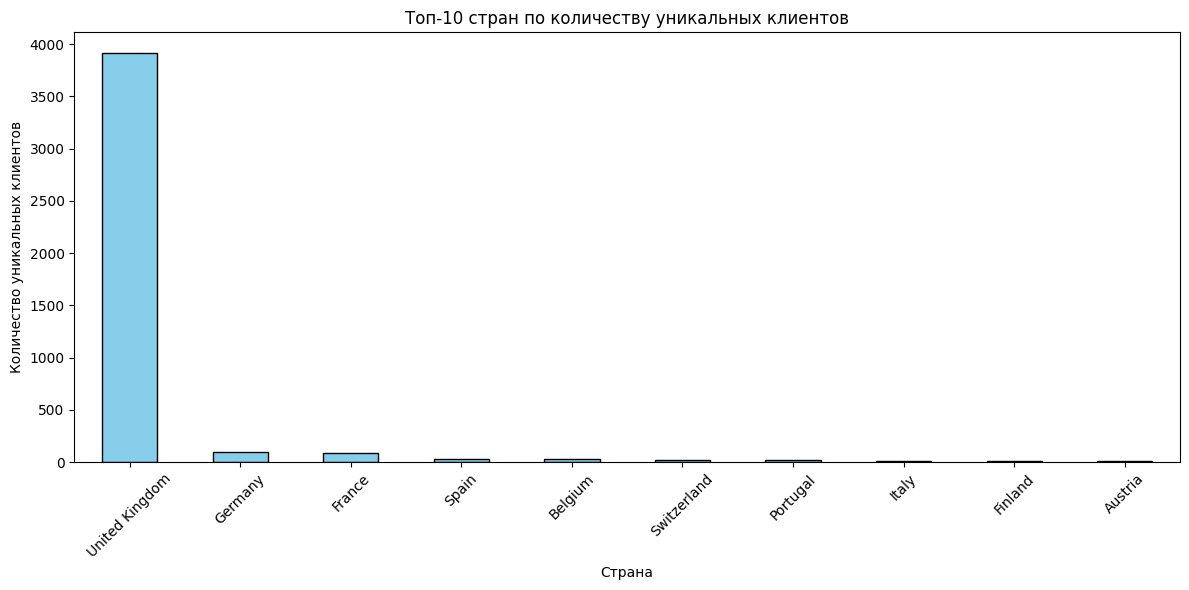

Страна с наибольшим количеством клиентов: United Kingdom


In [25]:
# Группируем по стране и считаем уникальных клиентов
customers_by_country = data_cleaned_final.groupby('Country')['CustomerID'].nunique().sort_values(ascending=False)

# Визуализация
plt.figure(figsize=(12, 6))
customers_by_country.head(10).plot(kind='bar', color='skyblue')
plt.title('Топ-10 стран по количеству уникальных клиентов')
plt.xlabel('Страна')
plt.ylabel('Количество уникальных клиентов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Определяем страну с наибольшим количеством клиентов
top_country = customers_by_country.index[0]
print(f"Страна с наибольшим количеством клиентов: {top_country}")

### Задание 4.2
Мы посмотрели на распределение клиентов в разрезе стран. А что насчёт заказов?

Постройте визуализацию и выделите топ-3 стран по количеству поступающих заказов.

* Великобритания (United Kingdom)
* Германия (Germany)
* Франция (France)
* Нидерланды (Netherlands)
* Ирландия (EIRE)
* Австралия (Australia)


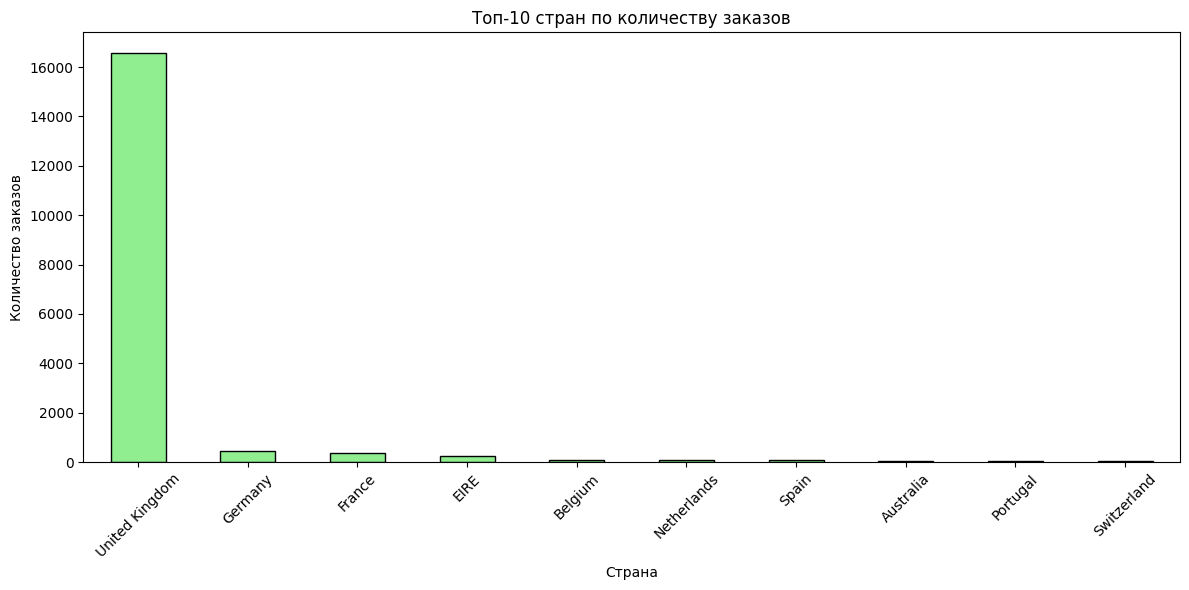

Топ-3 страны по количеству заказов: United Kingdom, Germany, France


In [26]:
# Группируем по стране и считаем количество уникальных заказов (InvoiceNo)
orders_by_country = data_cleaned_final.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False)

# Визуализация
plt.figure(figsize=(12, 6))
orders_by_country.head(10).plot(kind='bar', color='lightgreen')
plt.title('Топ-10 стран по количеству заказов')
plt.xlabel('Страна')
plt.ylabel('Количество заказов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Топ-3 страны
top_3_countries = orders_by_country.head(3).index.tolist()
print(f"Топ-3 страны по количеству заказов: {', '.join(top_3_countries)}")

### Задание 4.3
Давайте добавим в датасет общую цену заказа, назовём её TotalPrice.
Общая цена заказа рассчитывается как:
 
 **общая цена = цена за единицу товара * (количество товаров в заказе - количество возвращённых товаров).**

Чему равна средняя общая стоимость заказов? Ответ приведите в фунтах стерлингов и округлите до целого числа.



In [27]:
# Создаем столбец TotalPrice
# Общая цена = UnitPrice * (Quantity - QuantityCanceled)
data_cleaned_final['TotalPrice'] = data_cleaned_final['UnitPrice'] * (data_cleaned_final['Quantity'] - data_cleaned_final['QuantityCanceled'])

# Рассчитываем среднюю общую стоимость заказов
average_total_price = data_cleaned_final['TotalPrice'].mean()
print(f"Средняя общая стоимость заказов: {average_total_price:.2f} фунтов стерлингов")

# Округляем до целого числа
average_total_price_rounded = round(average_total_price)
print(f"Средняя общая стоимость заказов (округленно): {average_total_price_rounded} фунтов стерлингов")

Средняя общая стоимость заказов: 21.13 фунтов стерлингов
Средняя общая стоимость заказов (округленно): 21 фунтов стерлингов


### Задание 4.4

Постройте визуализацию и выделите топ-3 стран, клиенты из которых приносят компании больше всего выручки:
* Великобритания (United Kingdom)
* Германия (Germany)
* Франция (France)
* Нидерланды (Netherlands)
* Ирландия (EIRE)
* Австралия (Australia)


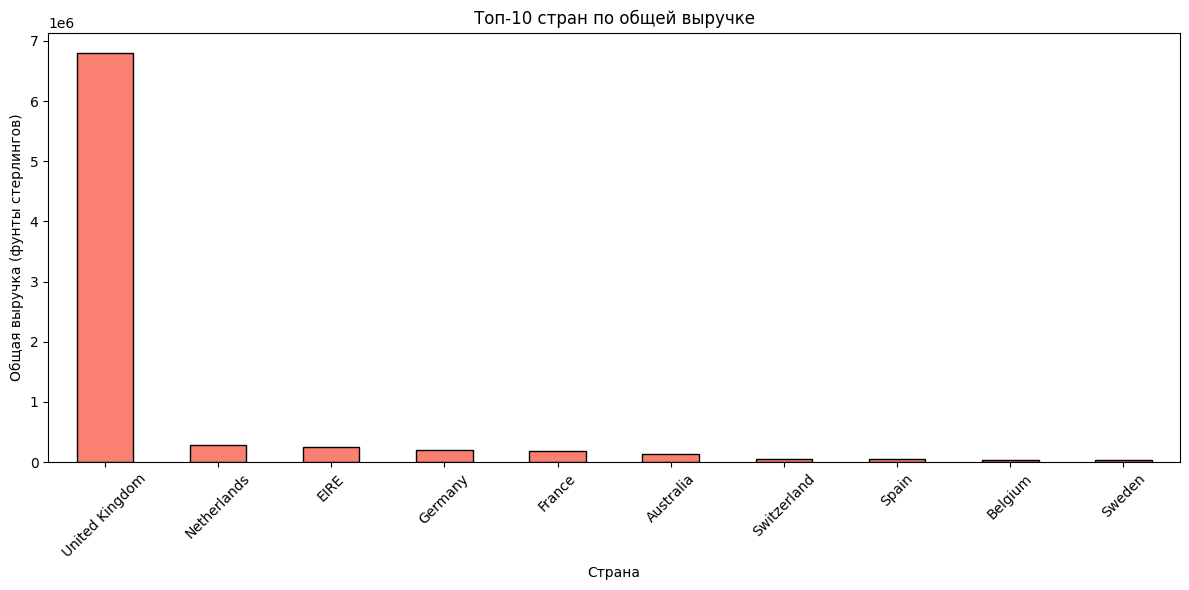

Топ-3 страны по общей выручке: United Kingdom, Netherlands, EIRE


In [28]:
# Группируем по стране и суммируем общую выручку
revenue_by_country = data_cleaned_final.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

# Визуализация
plt.figure(figsize=(12, 6))
revenue_by_country.head(10).plot(kind='bar', color='salmon')
plt.title('Топ-10 стран по общей выручке')
plt.xlabel('Страна')
plt.ylabel('Общая выручка (фунты стерлингов)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Топ-3 страны
top_3_revenue_countries = revenue_by_country.head(3).index.tolist()
print(f"Топ-3 страны по общей выручке: {', '.join(top_3_revenue_countries)}")

Теперь займёмся временными характеристиками.


### Задание 4.5
Добавьте в таблицу с транзакциями признаки месяца, дня недели и часа совершения покупки.

Постройте визуализацию, отражающую распределение суммарной выручки от заказов по месяцам. Укажите номер самого прибыльного для компании месяца. Предположите, почему так происходит.

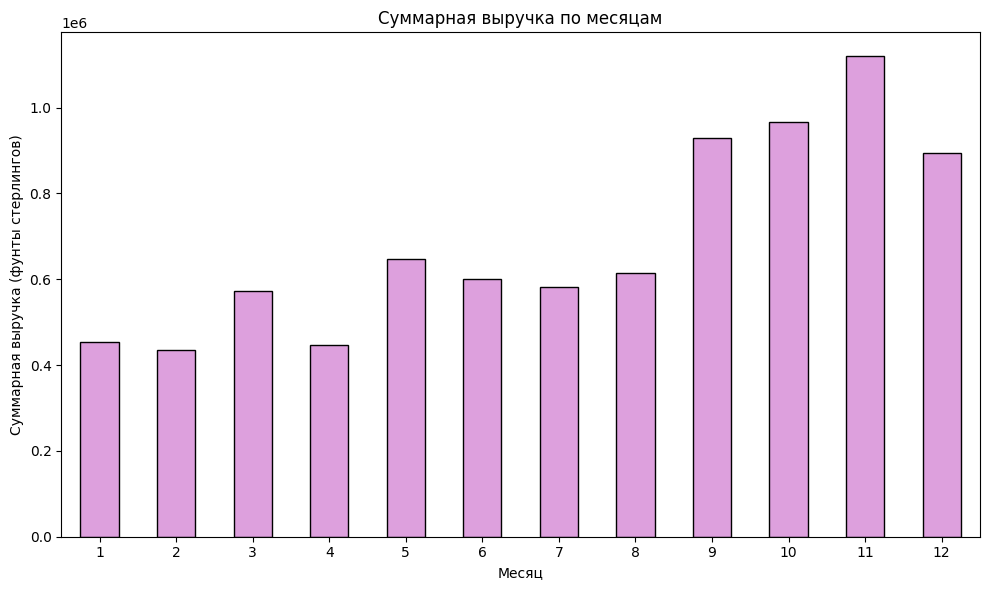

Самый прибыльный месяц: 11 (выручка: 1119641.60 фунтов стерлингов)


In [29]:
# Добавляем признаки месяца, дня недели и часа
data_cleaned_final['Month'] = data_cleaned_final['InvoiceDate'].dt.month
data_cleaned_final['DayOfWeek'] = data_cleaned_final['InvoiceDate'].dt.dayofweek  # 0 - Monday, 6 - Sunday
data_cleaned_final['Hour'] = data_cleaned_final['InvoiceDate'].dt.hour

# Группируем по месяцам и суммируем выручку
monthly_revenue = data_cleaned_final.groupby('Month')['TotalPrice'].sum()

# Визуализация
plt.figure(figsize=(10, 6))
monthly_revenue.plot(kind='bar', color='plum')
plt.title('Суммарная выручка по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Суммарная выручка (фунты стерлингов)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Самый прибыльный месяц
most_profitable_month = monthly_revenue.idxmax()
print(f"Самый прибыльный месяц: {most_profitable_month} (выручка: {monthly_revenue.max():.2f} фунтов стерлингов)")

### Задание 4.6
Постройте визуализацию количества заказов для каждого дня недели. Укажите день недели, в который, согласно данным, не совершено ни одного заказа:
* Понедельник
* Вторник
* Среда
* Четверг
* Пятница
* Суббота 
* Воскресенье


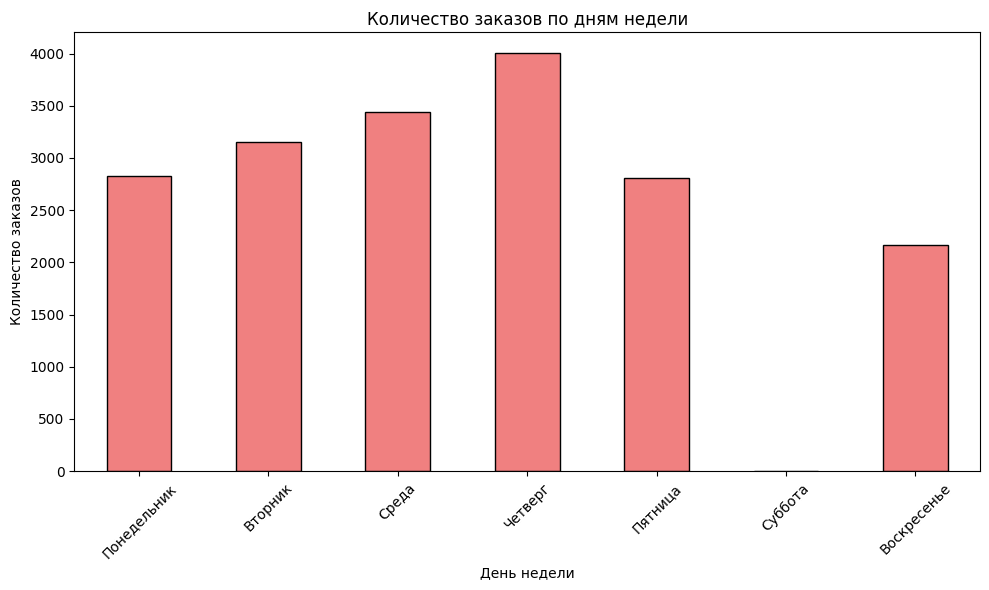

Дни без заказов: Суббота


In [30]:
# Группируем по дню недели и считаем количество заказов
orders_by_day = data_cleaned_final.groupby('DayOfWeek')['InvoiceNo'].nunique()

# Создаем список названий дней недели
days = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']

# Визуализация
plt.figure(figsize=(10, 6))

# Создаем полный индекс от 0 до 6 и заполняем отсутствующие дни нулями
full_index = range(7)
orders_by_day_full = orders_by_day.reindex(full_index, fill_value=0)

# Строим график
orders_by_day_full.plot(kind='bar', color='lightcoral')
plt.title('Количество заказов по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество заказов')
plt.xticks(ticks=range(7), labels=days, rotation=45)
plt.tight_layout()
plt.show()

# Определяем день с нулевым количеством заказов
days_with_zero_orders = [days[i] for i in range(7) if orders_by_day_full.iloc[i] == 0]
if days_with_zero_orders:
    print(f"Дни без заказов: {', '.join(days_with_zero_orders)}")
else:
    print("Заказы есть во все дни недели.")

### Задание 4.7
Выделите дату из признака времени совершения транзакции.
Сгруппируйте данные по датам и часам совершения транзакции и найдите количество заказов на каждый день-час. Затем найдите среднее количество ежедневно поступающих заказов в каждый из часов.

Постройте визуализацию, отражающую распределение среднего количества ежедневно поступающих заказов по времени суток (часу совершения транзакции).

Выберите верные утверждения:
* Больше всего заказов совершается в дневное время в интервале от 18 до 20 часов
* Больше всего заказов совершается в вечернее время в интервале от 10 до 15 часов
* Начиная с 21 часа вечера и до 6 утра (не включительно) заказы не поступают 
* Заказы поступают во все периоды дня


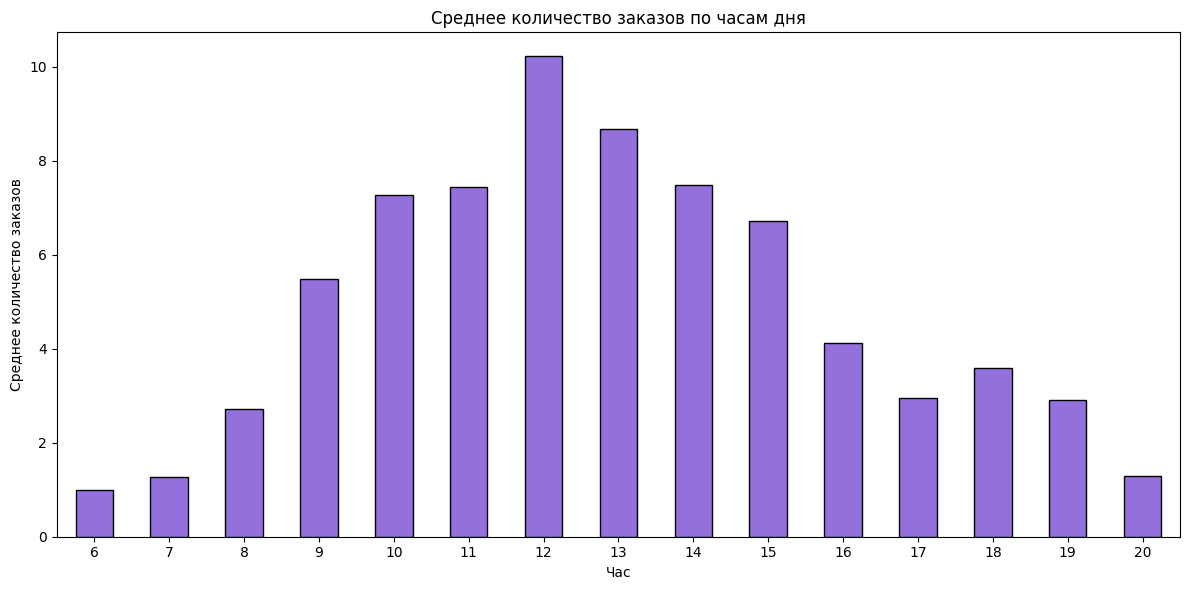

In [31]:
# Группируем по дате и часу, считаем количество заказов
orders_by_date_hour = data_cleaned_final.groupby([data_cleaned_final['InvoiceDate'].dt.date, 'Hour'])['InvoiceNo'].nunique()

# Группируем по часу и находим среднее количество заказов
avg_orders_by_hour = orders_by_date_hour.groupby('Hour').mean()

# Визуализация
plt.figure(figsize=(12, 6))
avg_orders_by_hour.plot(kind='bar', color='mediumpurple')
plt.title('Среднее количество заказов по часам дня')
plt.xlabel('Час')
plt.ylabel('Среднее количество заказов')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. RFM-сегментация клиентов: часть 1

Мы добрались до самой интересной части нашей задачи. Нам предстоит сформировать признаки, на основе которых мы будем производить сегментацию клиентов.

Для этого давайте познакомимся с очень популярным методом для анализа потребительской ценности под названием RFM. 

<center> <img src=https://miro.medium.com/max/1400/1*uYQjy9SUjW7iWHc2gGanQQ.png align="right" width="400"/> </center>

Метод заключается в группировке клиентов на основе следующих параметров:
* Recency (Давность) — давность последней покупки клиента;
* Frequency (Частота) — общее количество покупок клиента;
* Monetary Value (Денежная ценность) — сколько денег потратил клиент.


Суть RFM-анализа состоит в том, что мы разделяем всех клиентов на группы в зависимости от того, как давно они сделали последнюю покупку, как часто покупали и насколько большой была сумма их заказов.

Например, вот так может выглядеть интерпретация кластеров для случая RF-сегментации (анализа на основе давности и частоты заказов клиента):

<img src=https://retailrocket.ru/wp-content/uploads/2017/06/rfm-1.png>

Задача маркетологов — вести клиента в зону лояльных.

Мы можем рассчитать RFM-характеристики для каждого из клиентов в нашем датасете и на их основе с помощью методов кластеризации построить подобные сегменты клиентов, привязанные к нашим данным.

### Задание 5.1

Итак, приступим к созданию нашей RFM-таблицы. 

Чтобы получить RFM-таблицу, нам необходимо сгруппировать данные по идентификаторам клиента и рассчитать следующие  агрегированные характеристики:

* Recency для i-го клиента рассчитывается как разница между датой и временем последнего заказа и точкой отсчёта, переведённая в дни:
    $$t_0-max(t_{i1}, t_{i2},..., t_{iM})$$

    где $t_{ij}$ — дата и время совершения i-ым клиентом своей j-ой покупки.

    В качестве точки отсчёта $t_0$ берём дату на один день «старше», чем все наши данные. Это будет 10 декабря 2011 года (в формате datetime — '2011-12-10 00:00:00').

* Frequency рассчитывается как общее количество уникальных заказов, которые совершил i-ый клиент.
* Monetary Value рассчитывается как общая сумма денег, которую i-ый клиент потратил на наши товары (с учетом возвратов).

Когда вы рассчитаете все характеристики, не забудьте дать столбцам результирующей таблицы соответствующие названия.

In [32]:
# Точка отсчета - 10 декабря 2011 года
snapshot_date = pd.Timestamp('2011-12-10 00:00:00')

# Группируем данные по клиентам
rfm_table = data_cleaned_final.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',  # Frequency
    'TotalPrice': 'sum'  # Monetary
}).reset_index()

# Переименовываем столбцы
rfm_table.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Выводим первые строки
print(rfm_table.head())

  CustomerID  Recency  Frequency  Monetary
0      12346      325          1      0.00
1      12347        2          7   4310.00
2      12348       75          4   1437.24
3      12349       18          1   1457.55
4      12350      310          1    294.40


1) Сколько клиентов совершили покупку более 200 дней назад?

2) Сколько заказов в среднем делает клиент (за представленный годовой период)? Ответ округлите до целого числа.

3) Чему равна общая сумма денег, которую потратил клиент с идентификатором 12360? Ответ приведите в фунтах стерлингов и округлите до целого числа.



In [33]:
# Сколько клиентов совершили покупку более 200 дней назад?
clients_200_days = rfm_table[rfm_table['Recency'] > 200].shape[0]
print(f"Клиентов, совершивших покупку более 200 дней назад: {clients_200_days}")

# Сколько заказов в среднем делает клиент?
avg_orders = rfm_table['Frequency'].mean()
print(f"Среднее количество заказов на клиента: {avg_orders:.2f}")

# Чему равна общая сумма денег, которую потратил клиент с идентификатором 12360?
client_12360_monetary = rfm_table[rfm_table['CustomerID'] == '12360']['Monetary'].values[0]
print(f"Клиент 12360 потратил: {client_12360_monetary:.2f} фунтов стерлингов")

Клиентов, совершивших покупку более 200 дней назад: 743
Среднее количество заказов на клиента: 4.25
Клиент 12360 потратил: 2302.06 фунтов стерлингов


Теперь давайте взглянем на коробчатые диаграммы для каждого из признаков:

In [34]:
# Устанавливаем CustomerID как индекс
rfm_table_indexed = rfm_table.set_index('CustomerID')

# Теперь можно использовать все столбцы
boxes = [px.box(rfm_table_indexed, x=column) for column in rfm_table_indexed.columns]

fig = make_subplots(
    rows=1, cols=3, 
    subplot_titles=("Recency", "Frequency", "Monetary")
)

for i, box in enumerate(boxes):
    fig.add_trace(boxes[i]['data'][0], row=1, col=i+1)

fig.update_layout(
    showlegend=True,
    width=1200,
    height=500,
    title_text="Распределение RFM-характеристик"
)
fig.write_html('plotly/boxplot_1.html')
fig.show()

Что интересного здесь можно увидеть? Есть клиенты с аномально большим количеством сделанных заказов (более 100 штук), а также клиенты, общая стоимость заказов которых превышает 190 тысяч фунтов стерлингов.

Чем это плохо? Выбросы могут отрицательно сказаться на результатах работы методов кластеризации, неустойчивых к ним, например алгоритма KMeans, поэтому хотелось бы от них избавиться. Однако терять много ценных данных о клиентах тоже не хочется, поэтому ограничимся верхней границей соответствующей квантили уровня 0.95. Таким образом, мы удалим данные тех клиентов, для которых значение параметра Frequency или параметра Monetary выше, чем у 95 % клиентов.


### Задание 5.2
Удалите из RFM-таблицы записи о клиентах, для которых выполняется хотя бы одно из условий:

$$frequency >frequency_{0.95}$$
$$monetary >monetary_{0.95}$$ 

где $frequency_{0.95}$ и $monetary_{0.95}$ - квантили уровня 0.95 для соответствующих признаков. 

Данные о скольких клиентах у вас остались в RFM-таблице?


In [35]:
# Находим квантили уровня 0.95
freq_95 = rfm_table['Frequency'].quantile(0.95)
monetary_95 = rfm_table['Monetary'].quantile(0.95)

print(f"Frequency 95-й перцентиль: {freq_95}")
print(f"Monetary 95-й перцентиль: {monetary_95:.2f}")

# Удаляем выбросы
rfm_table_cleaned = rfm_table[
    (rfm_table['Frequency'] <= freq_95) &
    (rfm_table['Monetary'] <= monetary_95)
].copy()

print(f"Количество клиентов после удаления выбросов: {len(rfm_table_cleaned)}")

Frequency 95-й перцентиль: 13.0
Monetary 95-й перцентиль: 5659.85
Количество клиентов после удаления выбросов: 4044


После удаления выбросов у вас должны получиться следующие коробчатые диаграммы:


In [36]:
# Выбираем только числовые столбцы для визуализации
rfm_numeric = rfm_table_cleaned[['Recency', 'Frequency', 'Monetary']]

boxes = [px.box(rfm_numeric, x=column) for column in rfm_numeric.columns]

fig = make_subplots(
    rows=1, cols=3, 
    subplot_titles=("Recency", "Frequency", "Monetary")
)

for i, box in enumerate(boxes):
    fig.add_trace(boxes[i]['data'][0], row=1, col=i+1)

fig.update_layout(
    showlegend=True,
    width=1200,
    height=500,
    title_text="Распределение RFM-характеристик после удаления выбросов"
)

fig.write_html('plotly/boxplot_2.html')
fig.show()

Мы наконец добрались до этапа кластеризации. Для начала нам необходимо оценить, как распределены наблюдения в пространстве признаков. Благо, у нас всего три параметра, по которым мы хотим кластеризовать клиентов, поэтому данные можно визуализировать в виде трёхмерной диаграммы рассеяния. 

Построим визуализацию нашего трёхмерного пространства признаков:


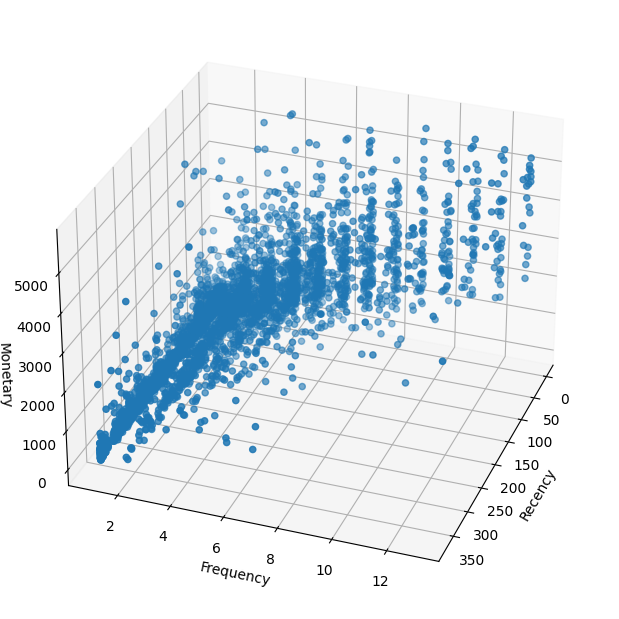

In [37]:
# создадим трёхмерный объект
fig = plt.figure(figsize=(6,6))
ax = Axes3D(fig)
# добавим дополнительную ось в объект картинки
fig.add_axes(ax)
ax.azim = 20
ax.elev = 30

# визуализируем данные, передав значения x, y, z, а также информацию о группировке данных по цветам
ax.scatter(
    rfm_table_cleaned['Recency'].to_list(), 
    rfm_table_cleaned['Frequency'].to_list(),
    rfm_table_cleaned['Monetary'].to_list()
)
# добавим оси
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary');


Что здесь можно увидеть? На самом деле, ничего конкретного. Да, видно, что есть клиенты с большими значениями параметров Monetary и Frequency — вероятно, это лучшие клиенты, которые покупают чаще всего и приносят больше всего денег. Однако по общей массе точек сложно сказать, сколько кластеров у нас есть — скорее даже кажется, что пространство не поддаётся кластеризации.

Давайте призовём на помощь методы снижения размерности.


### Задание 5.3
Начнём с метода главных компонент (PCA). Нам известно, что для его стабильной работы данные необходимо стандартизировать/нормализовать. 

Давайте для удобства обернём эти шаги по предобработке данных в pipeline.

Создайте pipeline, в котором будут следующие шаги:
* стандартизация с помощью StandardScaler с параметрами по умолчанию; 
* метод главных компонент с двумя компонентами.

Обучите ваш pipeline на RFM-таблице, очищенной от выбросов, и примените к ней трансформацию.

Какую долю дисперсии исходных данных объясняет первая главная компонента? Ответ округлите до двух знаков после точки-разделителя.



In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
# Создаем pipeline
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2))
])

# Обучаем pipeline и трансформируем данные
rfm_scaled = pca_pipeline.fit_transform(rfm_table_cleaned[['Recency', 'Frequency', 'Monetary']])

# Получаем объясненную дисперсию
explained_variance_ratio = pca_pipeline.named_steps['pca'].explained_variance_ratio_
print(f"Доля дисперсии, объясняемая первой компонентой: {explained_variance_ratio[0]:.2f}")

# Создаем DataFrame с результатами PCA
rfm_table_processed = pd.DataFrame(rfm_scaled, columns=['axis-1', 'axis-2'])
rfm_table_processed.index = rfm_table_cleaned.index

print(rfm_table_processed.head())

Доля дисперсии, объясняемая первой компонентой: 0.68
     axis-1    axis-2
0 -2.135201  1.401596
1  3.447125  0.852872
2  0.629103  0.083217
3  0.152932 -0.720954
4 -1.888765  1.382645


Визуализировав пространство главных компонент после декомпозиции мы получим следующую картину:

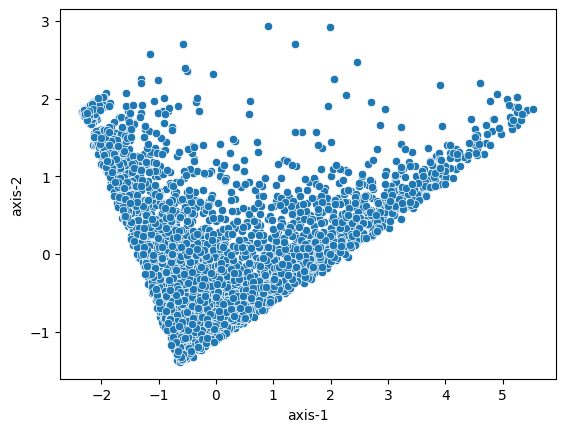

In [39]:
sns.scatterplot(data=rfm_table_processed, x='axis-1', y='axis-2');

Попробуем разделить это пространство главных компонент на сегменты. 

### Задание 5.4
Попробуем воспользоваться методом k-means. 

Подберите оптимальное количество кластеров для метода k-means с помощью коэффициента силуэта, перебирая возможные значения от 2 до 10 включительно. 

В качестве значения параметра random_state возьмите число 42. Остальные параметры оставьте по умолчанию.

1) Судя по полученным результатам, какое количество кластеров лучше всего взять?

2) Чему равно максимальное значение коэффициента силуэта? Ответ округлите до двух знаков после точки-разделителя.


In [40]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Перебираем количество кластеров от 2 до 10
silhouette_scores_kmeans = []
kmeans_models = []

for n_clusters in range(2, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_table_processed)
    score = silhouette_score(rfm_table_processed, labels)
    silhouette_scores_kmeans.append(score)
    kmeans_models.append(kmeans)
    print(f"K-Means, кластеров: {n_clusters}, силуэт: {score:.4f}")

# Оптимальное количество кластеров
optimal_kmeans_clusters = range(2, 11)[silhouette_scores_kmeans.index(max(silhouette_scores_kmeans))]
max_kmeans_score = max(silhouette_scores_kmeans)

print(f"\nОптимальное количество кластеров для K-Means: {optimal_kmeans_clusters}")
print(f"Максимальное значение коэффициента силуэта: {max_kmeans_score:.2f}")

K-Means, кластеров: 2, силуэт: 0.5003
K-Means, кластеров: 3, силуэт: 0.5242
K-Means, кластеров: 4, силуэт: 0.4976
K-Means, кластеров: 5, силуэт: 0.4545
K-Means, кластеров: 6, силуэт: 0.4480
K-Means, кластеров: 7, силуэт: 0.4203
K-Means, кластеров: 8, силуэт: 0.4207
K-Means, кластеров: 9, силуэт: 0.4090
K-Means, кластеров: 10, силуэт: 0.3978

Оптимальное количество кластеров для K-Means: 3
Максимальное значение коэффициента силуэта: 0.52


### Задание 5.5
Теперь возьмём EM-алгоритм.

Подберите оптимальное количество кластеров для EM-алгоритма (GaussianMixture) с помощью коэффициента силуэта, перебирая возможные значения от 2 до 10 включительно.
В качестве значения параметра random_state возьмите число 42. Остальные параметры оставьте по умолчанию.


1) Судя по полученным результатам, какое количество кластеров лучше всего взять?

2) Чему равно максимальное значение коэффициента силуэта? Ответ округлите до двух знаков после точки-разделителя.


In [41]:
from sklearn.mixture import GaussianMixture

# Перебираем количество кластеров от 2 до 10
silhouette_scores_gmm = []
gmm_models = []

for n_clusters in range(2, 11):
    gmm = GaussianMixture(n_components=n_clusters, random_state=42)
    labels = gmm.fit_predict(rfm_table_processed)
    score = silhouette_score(rfm_table_processed, labels)
    silhouette_scores_gmm.append(score)
    gmm_models.append(gmm)
    print(f"GMM, кластеров: {n_clusters}, силуэт: {score:.4f}")

# Оптимальное количество кластеров
optimal_gmm_clusters = range(2, 11)[silhouette_scores_gmm.index(max(silhouette_scores_gmm))]
max_gmm_score = max(silhouette_scores_gmm)

print(f"\nОптимальное количество кластеров для GMM: {optimal_gmm_clusters}")
print(f"Максимальное значение коэффициента силуэта: {max_gmm_score:.2f}")

GMM, кластеров: 2, силуэт: 0.3425
GMM, кластеров: 3, силуэт: 0.4361
GMM, кластеров: 4, силуэт: 0.3501
GMM, кластеров: 5, силуэт: 0.2470
GMM, кластеров: 6, силуэт: 0.2667
GMM, кластеров: 7, силуэт: 0.1989
GMM, кластеров: 8, силуэт: 0.1969
GMM, кластеров: 9, силуэт: 0.1576
GMM, кластеров: 10, силуэт: 0.1094

Оптимальное количество кластеров для GMM: 3
Максимальное значение коэффициента силуэта: 0.44


### Задание 5.6
Давайте посмотрим на распределение кластеров.

1) Сначала нужно определить лучшую модель. Для какой модели с оптимальным количеством кластеров коэффициент силуэта наибольший?
* K-Means
* GaussianMixture


2) Обучите лучшую модель с подобранным ранее количеством кластеров на декомпозированных данных. 
Сколько клиентов попало в самый большой кластер?



In [42]:
# Сравниваем лучшие модели
best_kmeans_score = max(silhouette_scores_kmeans)
best_gmm_score = max(silhouette_scores_gmm)

print(f"Лучший силуэт K-Means: {best_kmeans_score:.2f}")
print(f"Лучший силуэт GMM: {best_gmm_score:.2f}")

# Обучаем лучшую модель
# Обучаем K-Means с оптимальным количеством кластеров (из Задания 5.4)
optimal_kmeans_clusters = 3

# Обучаем модель K-Means
kmeans_final = KMeans(n_clusters=optimal_kmeans_clusters, random_state=42, n_init=10)
best_labels = kmeans_final.fit_predict(rfm_table_processed)

# Количество клиентов в самом большом кластере
from collections import Counter
cluster_counts = Counter(best_labels)
largest_cluster_size = max(cluster_counts.values())
print(f"Количество клиентов в самом большом кластере: {largest_cluster_size}")

Лучший силуэт K-Means: 0.52
Лучший силуэт GMM: 0.44
Количество клиентов в самом большом кластере: 2269


Визуализируем результаты кластеризации:

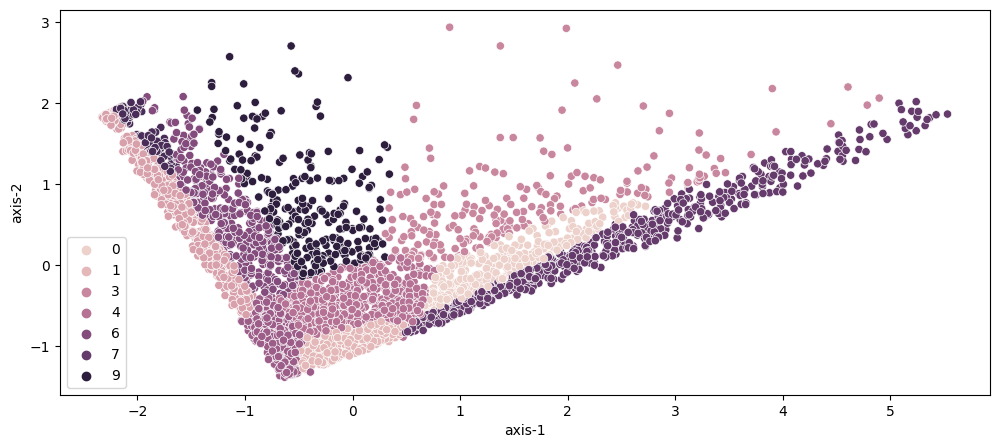

In [43]:
fig = plt.figure(figsize=(12, 5))
sns.scatterplot(
    data=rfm_table_processed, 
    x='axis-1', 
    y='axis-2', 
    hue=labels,
);

Итак, у нас есть три сегмента клиентов. Давайте попробуем составить профиль для этих сегментов.

### Задание 5.7

Для составления профиля кластеров нам необходимо вернуться от декомпозированных данных к RFM-таблице, очищенной от выбросов.  Сгруппируйте RFM-таблицу по полученным кластерам и рассчитайте среднее по каждому из признаков.

Чему равно максимальное среднее значение признака Frequency в полученной таблице? Ответ округлите до целого числа.

In [44]:
# Добавляем метки кластеров в RFM-таблицу
rfm_table_cleaned['Cluster'] = best_labels

# Группируем по кластерам и считаем средние значения
cluster_profiles = rfm_table_cleaned.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

print("Профили кластеров:")
print(cluster_profiles.round(2))

# Находим максимальное среднее значение Frequency
max_avg_frequency = cluster_profiles['Frequency'].max()
print(f"\nМаксимальное среднее значение Frequency: {max_avg_frequency:.2f}")

# Округляем до целого числа
print(f"Максимальное среднее значение Frequency (округленно): {round(max_avg_frequency)}")

Профили кластеров:
         Recency  Frequency  Monetary
Cluster                              
0         253.47       1.40    386.28
1          31.94       7.07   2657.75
2          51.22       2.33    660.07

Максимальное среднее значение Frequency: 7.07
Максимальное среднее значение Frequency (округленно): 7


### Полярная диаграмма
Сейчас мы познакомимся с одним из способов визуализации профиля кластеров — Radar Chart (полярная, или лепестковая, диаграмма). Это графическое представление значений нескольких эквивалентных категорий в форме «паутины».
Radar Chart очень часто используется в контексте определения профиля кластеров. На концах «паутины» откладываются оси, которые соответствуют признакам, описывающим объекты. На каждой из осей для каждого кластера откладываются средние значения соответствующих характеристик. Соединив точки по осям, мы получаем многоугольник. 
Пример полярной диаграммы для задачи кластеризации учеников по интересам:

<img src=https://www.datanovia.com/en/wp-content/uploads/2020/12/radar-chart-in-r-customized-fmstb-radar-chart-1.png width=500>

На данной диаграмме мы видим визуализацию признаков для одного из кластеров. Видно, что ученики, принадлежащие к данному кластеру, в большей степени увлекаются музыкой (Music), а в меньшей степени — программированием (Programm).

В модуле graph_objects библиотеки plotly есть встроенная функция Scatterpolar, которая позволяет построить полярную диаграмму. На основе этой функции мы реализовали собственную функцию plot_cluster_profile(), которая позволяет визуализировать профиль каждого из кластеров в виде полярной диаграммы. У этой функции два параметра: grouped_data — сгруппированные по кластерам характеристики объектов (клиентов), n_clusters — количество кластеров. 

Главное условие использования полярной диаграммы — все признаки должны быть приведены к единому масштабу с помощью нормализации, где 1 будет означать максимум, а 0 — минимум. Шаг с нормализацией мы также добавили в реализацию функции plot_cluster_profile().

In [45]:
def plot_cluster_profile(grouped_data, n_clusters):
    # Нормализуем сгруппированные данные, приводя их к масштабу 0-1.
    scaler = preprocessing.MinMaxScaler()
    grouped_data = pd.DataFrame(scaler.fit_transform(grouped_data), columns=grouped_data.columns)
    # Создаем список признаков
    features = grouped_data.columns
    # Создаем пустую фигуру
    fig = go.Figure()
    # В цикле визуализируем полярную диаграмму для каждого кластера
    for i in range(n_clusters):
        # Создаем полярную диаграмму и добавляем ее на общий график
        fig.add_trace(go.Scatterpolar(
            r=grouped_data.iloc[i].values, # радиусы
            theta=features, # название засечек
            fill='toself', # заливка многоугольника цветом
            name=f'Cluster {i}', # название - номер кластера
        ))
    # Обновляем параметры фигуры
    fig.update_layout(
        showlegend=True, # отображение легенды
        autosize=False, # устаналиваем свои размеры графика
        width=800, # ширина (в пикселях)
        height=800, # высота (в пикселях)
    )
    # Отображаем фигуру
    fig.show()

Теперь у нас есть удобный инструмент для анализа профиля кластеров. Давайте воспользуемся им.


### Задание 5.8

Визуализируйте профили кластеров в виде полярной диаграммы на основе средних RFM-характеристик, вычисленных для каждого кластера. 

Проанализируйте кластеры и на основе анализа сопоставьте номер кластера и его описание.

Описание кластера:
* Кластер соответствует «лояльным» клиентам, которые приносят наибольший доход, совершают покупки чаще всего, а давность их последней покупки наименьшая.
* Кластер соответствует «промежуточным» клиентам, которые являются активными, но покупают не так часто и много, как лояльные клиенты. В то же время эти клиенты не являются «потерянными».
* Кластер соответствует «потерянным» клиентам, которые купили меньше всего товара, и их последняя покупка была совершена очень давно.


In [46]:
# Определяем функцию для построения полярной диаграммы
def plot_cluster_profile(grouped_data, n_clusters):
    # Нормализуем сгруппированные данные, приводя их к масштабу 0-1.
    scaler = preprocessing.MinMaxScaler()
    grouped_data_norm = pd.DataFrame(scaler.fit_transform(grouped_data), columns=grouped_data.columns)
    
    # Создаем список признаков
    features = grouped_data_norm.columns
    
    # Создаем пустую фигуру
    fig = go.Figure()
    
    # В цикле визуализируем полярную диаграмму для каждого кластера
    for i in range(n_clusters):
        fig.add_trace(go.Scatterpolar(
            r=grouped_data_norm.iloc[i].values,
            theta=features,
            fill='toself',
            name=f'Cluster {i}',
        ))
    
    # Обновляем параметры фигуры
    fig.update_layout(
        showlegend=True,
        autosize=False,
        width=800,
        height=800,
    )
    fig.show()

# Визуализируем профили кластеров
plot_cluster_profile(cluster_profiles, len(cluster_profiles))

### 4. RFM-сегментация клиентов: часть 2

Итак, с помощью RFM-анализа нам удалось выделить три сегмента клиентов. Однако в маркетинге принято оперировать большим их количеством: обычно маркетологи стараются создать стратегию хотя бы для пяти-семи клиентских сегментов в градации от «лояльных» до «потерянных» с промежуточными категориями.

Поэтому, получив обратную связь от маркетологов, мы вновь принимаемся за работу, пытаясь модифицировать полученное решение.

Ранее мы производили кластеризацию в пространстве главных компонент. Вспомним, что PCA является линейным методом отображения исходного пространства признаков в его сжатую версию.

А что если использовать нелинейную трансформацию? Например, алгоритм снижения размерности t-SNE. Давайте попробуем и посмотрим, что получится.

### Задание 6.1
Воспользуемся алгоритмом t-SNE и трансформируем RFM-таблицу, очищенную от выбросов, в двухмерное представление. Также заранее позаботимся о масштабировании признаков.

Давайте для удобства обернём шаги по предобработке данных в pipeline.

Создайте pipeline, который будет содержать следующие шаги:
* стандартизация с помощью StandardScaler с параметрами по умолчанию; 
* алгоритм t-SNE с двумя компонентами, параметрами perplexity=50 и random_state=100.

Обучите ваш pipeline на RFM-таблице (очищенной от выбросов), полученной ранее, и примените к ней трансформацию.

Чему равно значение дивергенции Кульбака — Лейблера для обученного алгоритма t-SNE? Ответ округлите до двух знаков после точки-разделителя.

**Примечание:**
Напомним, что дивергенция Кульбака-Лейблера - это функция потерь, которая минимизируется при обучения алгоритма t-SNE. Она показывает меру расстояния между двумя распределениями. 

Оптимальное значение данной характеристики, найденное в процессе обучения алгоритма t-SNE, хранится в атрибуте kl_divergence_ объекта класса TSNE из библиотеки sklearn. Конечно же, предварительно модель необходимо обучить, чтобы получить это значение.



In [50]:
from sklearn.manifold import TSNE

# Создаем pipeline с t-SNE
tsne_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('tsne', TSNE(n_components=2, perplexity=50, random_state=100))
])

# Обучаем pipeline и трансформируем данные
rfm_tsne = tsne_pipeline.fit_transform(rfm_table_cleaned[['Recency', 'Frequency', 'Monetary']])

# Получаем значение дивергенции Кульбака-Лейблера
kl_divergence = tsne_pipeline.named_steps['tsne'].kl_divergence_
print(f"Дивергенция Кульбака-Лейблера: {kl_divergence:.2f}")

# Создаем DataFrame с результатами t-SNE
rfm_table_processed_tsne = pd.DataFrame(rfm_tsne, columns=['axis-1', 'axis-2'])
rfm_table_processed_tsne.index = rfm_table_cleaned.index

print(rfm_table_processed_tsne.head())

Дивергенция Кульбака-Лейблера: 0.54
      axis-1     axis-2
0  -5.096237  32.750000
1  19.839493  30.269058
2  30.227396  -1.920902
3   9.074645 -19.684454
4  -8.583499  27.215914


Визуализировав пространство после декомпозиции с помощью t-SNE, мы получим следующую картину:


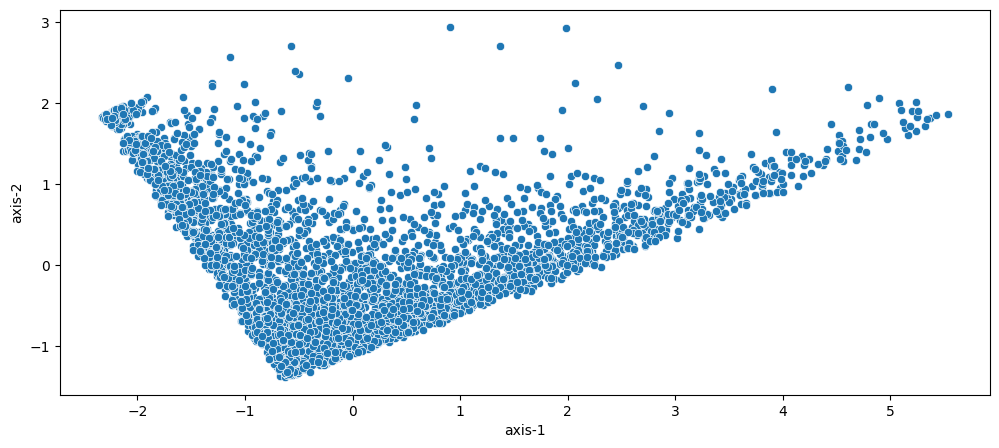

In [51]:
fig = plt.figure(figsize=(12, 5))
sns.scatterplot(data=rfm_table_processed, x='axis-1', y='axis-2');

Как и ожидалось от t-SNE, алгоритм сгруппировал наиболее похожие объекты в подобие кластеров, причём эти кластеры легко определить.

Теперь давайте воспользуемся алгоритмами кластеризации, чтобы сформировать новые сегменты клиентов.


### Задание 6.2
Попробуем воспользоваться методом k-means. 
Подберите оптимальное количество кластеров для метода k-means с помощью коэффициента силуэта, перебирая возможные значения от 3 до 8 включительно. 
В качестве значения параметра random_state возьмите число 42. Остальные параметры оставьте по умолчанию.

1) Судя по полученным результатам, какое количество кластеров лучше всего взять?

2) Чему равно максимальное значение коэффициента силуэта? Ответ округлите до двух знаков после точки-разделителя.



In [52]:
# Перебираем количество кластеров от 3 до 8
silhouette_scores_kmeans_tsne = []
kmeans_models_tsne = []

for n_clusters in range(3, 9):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_table_processed_tsne)
    score = silhouette_score(rfm_table_processed_tsne, labels)
    silhouette_scores_kmeans_tsne.append(score)
    kmeans_models_tsne.append(kmeans)

# Оптимальное количество кластеров
optimal_kmeans_tsne_clusters = range(3, 9)[silhouette_scores_kmeans_tsne.index(max(silhouette_scores_kmeans_tsne))]
max_kmeans_tsne_score = max(silhouette_scores_kmeans_tsne)

print(f"\nОптимальное количество кластеров для K-Means (t-SNE): {optimal_kmeans_tsne_clusters}")
print(f"Максимальное значение коэффициента силуэта: {max_kmeans_tsne_score:.2f}")


Оптимальное количество кластеров для K-Means (t-SNE): 7
Максимальное значение коэффициента силуэта: 0.48


### Задание 6.3
Попробуем воспользоваться EM-алгоритом. 

Подберите оптимальное количество кластеров для EM-алгоритма (GaussianMixture)  с помощью коэффициента силуэта, перебирая возможные значения от 3 до 8 включительно. 

В качестве значения параметра random_state возьмите число 42. Остальные параметры оставьте по умолчанию.


1) Судя по полученным результатам, какое количество кластеров лучше всего взять?

2) Чему равно максимальное значение коэффициента силуэта? Ответ округлите до двух знаков после точки-разделителя.

In [53]:
# Перебираем количество кластеров от 3 до 8
silhouette_scores_gmm_tsne = []
gmm_models_tsne = []

for n_clusters in range(3, 9):
    gmm = GaussianMixture(n_components=n_clusters, random_state=42)
    labels = gmm.fit_predict(rfm_table_processed_tsne)
    score = silhouette_score(rfm_table_processed_tsne, labels)
    silhouette_scores_gmm_tsne.append(score)
    gmm_models_tsne.append(gmm)

# Оптимальное количество кластеров
optimal_gmm_tsne_clusters = range(3, 9)[silhouette_scores_gmm_tsne.index(max(silhouette_scores_gmm_tsne))]
max_gmm_tsne_score = max(silhouette_scores_gmm_tsne)

print(f"\nОптимальное количество кластеров для GMM (t-SNE): {optimal_gmm_tsne_clusters}")
print(f"Максимальное значение коэффициента силуэта: {max_gmm_tsne_score:.2f}")


Оптимальное количество кластеров для GMM (t-SNE): 4
Максимальное значение коэффициента силуэта: 0.47


### Задание 6.4
Наконец, попробуем воспользоваться алгоритмом алгомеративной кластеризации (AgglomerativeClustering).

Подберите оптимальное количество кластеров для алгоритма агломеративной кластеризации с помощью коэффициента силуэта, перебирая возможные значения от 2 до 8 включительно. 

Все параметры, за исключением числа кластеров, оставьте по умолчанию.


1) Судя по полученным результатам, какое количество кластеров лучше всего взять?

2) Чему равно максимальное значение коэффициента силуэта? Ответ округлите до двух знаков после точки-разделителя.



In [54]:
from sklearn.cluster import AgglomerativeClustering

# Перебираем количество кластеров от 2 до 8
silhouette_scores_agg_tsne = []
agg_models_tsne = []

for n_clusters in range(2, 9):
    agg = AgglomerativeClustering(n_clusters=n_clusters)
    labels = agg.fit_predict(rfm_table_processed_tsne)
    score = silhouette_score(rfm_table_processed_tsne, labels)
    silhouette_scores_agg_tsne.append(score)
    agg_models_tsne.append(agg)

# Оптимальное количество кластеров
optimal_agg_tsne_clusters = range(2, 9)[silhouette_scores_agg_tsne.index(max(silhouette_scores_agg_tsne))]
max_agg_tsne_score = max(silhouette_scores_agg_tsne)

print(f"\nОптимальное количество кластеров для Agglomerative (t-SNE): {optimal_agg_tsne_clusters}")
print(f"Максимальное значение коэффициента силуэта: {max_agg_tsne_score:.2f}")


Оптимальное количество кластеров для Agglomerative (t-SNE): 8
Максимальное значение коэффициента силуэта: 0.48


### Задание 6.5
Давайте посмотрим на распределение кластеров.

1) Сначала нужно определить лучшую модель. Для какой модели с оптимальным количеством кластеров коэффициент силуэта наибольший?
* K-Means
* GaussianMixture
* AgglomerativeClustering


2) Обучите лучшую модель с подобранным ранее количеством кластеров на декомпозированных данных. 
Сколько клиентов попало в самый большой кластер?



In [58]:
# Сравниваем лучшие модели
best_kmeans_tsne_score = max(silhouette_scores_kmeans_tsne)
best_gmm_tsne_score = max(silhouette_scores_gmm_tsne)
best_agg_tsne_score = max(silhouette_scores_agg_tsne)

print(f"Лучший силуэт K-Means (t-SNE): {best_kmeans_tsne_score:.4f}")
print(f"Лучший силуэт GMM (t-SNE): {best_gmm_tsne_score:.4f}")
print(f"Лучший силуэт Agglomerative (t-SNE): {best_agg_tsne_score:.4f}")

# Обучаем K-Means с оптимальным количеством кластеров
best_model_tsne = KMeans(n_clusters=optimal_kmeans_tsne_clusters, random_state=42, n_init=10)
best_labels_tsne = best_model_tsne.fit_predict(rfm_table_processed_tsne)

#  Количество клиентов в самом большом кластере
cluster_counts_tsne = Counter(best_labels_tsne)
largest_cluster_size_tsne = max(cluster_counts_tsne.values())
print(f"Количество клиентов в самом большом кластере: {largest_cluster_size_tsne}")

Лучший силуэт K-Means (t-SNE): 0.4845
Лучший силуэт GMM (t-SNE): 0.4688
Лучший силуэт Agglomerative (t-SNE): 0.4790
Количество клиентов в самом большом кластере: 914


Визуализируем результаты кластеризации:

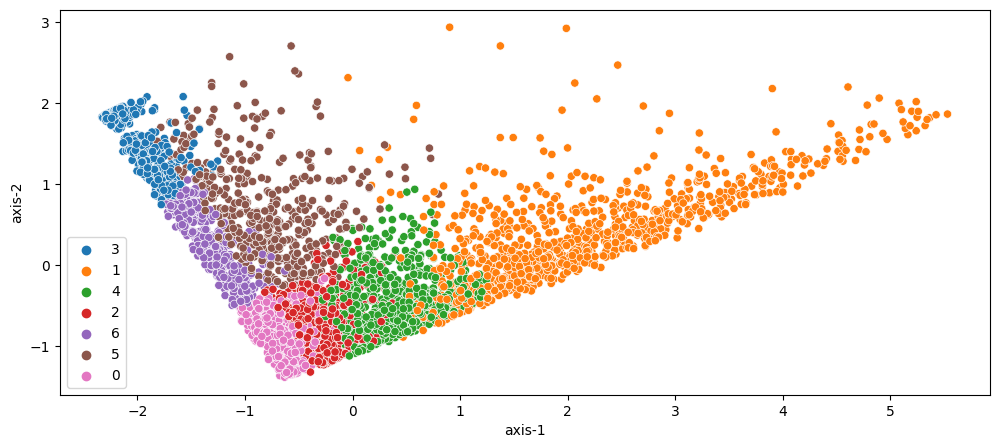

In [59]:
fig = plt.figure(figsize=(12, 5))
sns.scatterplot(data=rfm_table_processed, x='axis-1', y='axis-2', hue=best_model_tsne.labels_.astype('str'));


Итак, у нас есть 7 сегментов клиентов. Давайте попробуем составить профиль для этих сегментов. 


### Задание 6.6

Для составления профиля кластеров нам необходимо вернуться от декомпозированных данных к RFM-таблице (очищенной от выбросов).

Сгруппируйте RFM-таблицу по полученным кластерам и рассчитайте среднее по каждому из признаков. Для наглядности округлите все значения в столбцах до целого числа.

Чему равно максимальное среднее значение признака Recency в полученной таблице? Ответ округлите до целого числа.

In [81]:
# Добавляем метки кластеров в RFM-таблицу 
rfm_table_cleaned['Cluster_tsne'] = best_labels_tsne

# Группируем по кластерам и считаем средние значения
cluster_profiles_tsne = rfm_table_cleaned.groupby('Cluster_tsne')[['Recency', 'Frequency', 'Monetary']].mean().round(0).astype(int)

# Находим максимальное среднее значение Recency
max_avg_recency = cluster_profiles_tsne['Recency'].max()
print(f"\nМаксимальное среднее значение Recency: {max_avg_recency}")


Максимальное среднее значение Recency: 313


### Задание 6.7
Визуализируйте профили кластеров в виде полярной диаграммы на основе средних RFM-характеристик, вычисленных для каждого кластера.

Проанализируйте кластеры и на основе анализа сопоставьте номер кластера и его описание.

* Кластер соответствует «лояльным» клиентам, которые приносят наибольший доход, совершают покупки чаще всего, а давность их последней покупки наименьшая.
* Кластер соответствует «перспективным» клиентам, которые являются активными покупателями, но покупают не так часто и не так много, как лояльные клиенты.
* Кластер соответствует «подвисшим» клиентам, которые относительно недавно сделали несколько заказов на небольшие суммы. Потенциально эти клиенты могут быть переведены в кластер «перспективных».
* Кластер соответствует клиентам «в зоне риска», которые несколько раз покупали товары на небольшие суммы, однако их последняя покупка была совершена более пяти месяцев назад.
* Кластер соответствует клиентам-«новичкам», которые относительно недавно сделали один заказ на небольшую сумму. 
* Кластер соответствует «спящим» или «почти потерянным» клиентам, которые сделали один заказ на маленькую сумму более семи месяцев назад и больше не возвращались.
* Кластер соответствует «потерянным» клиентам, которые купили меньше всего товара, и их последняя покупка была совершена около года назад.



In [62]:
# Визуализируем профили кластеров
plot_cluster_profile(cluster_profiles_tsne, len(cluster_profiles_tsne))

## 7. RFM-кластеризация клиентов: часть 3

Мы построили модель кластеризации для части клиентов.Но как сделать предсказание сегмента для клиентов, которые не попали в обучающую выборку?

Вы, вероятно, скажете: «Воспользоваться методом predict()!»

Верно, однако всё не так просто.

Вспомним, что мы обучали наши алгоритмы кластеризации на сжатом с помощью t-SNE пространстве признаков. То есть, чтобы сделать предсказание для новых объектов, не попавших в выборку, нам необходимо будет совершить трансформацию признаков этих объектов в новое сжатое пространство. 

Однако проблема t-SNE заключается в том, что алгоритм непараметрический. Это значит, что он, в отличие от таких алгоритмов, как PCA и SVD, не создаёт явной функции отображения. Проще говоря, алгоритм трансформирует пространство признаков для обучающей выборки, но не запоминает, каким образом это делает. Это значит, что, передав в алгоритм новые объекты для сжатия пространства, мы получим абсолютно новое представление пространства, не имеющее отношения к тому, что мы построили для обучающей выборки. То есть произойдёт искажение, что может привести к неверным результатам кластеризации.

Именно поэтому у класса TSNE из библиотеки sklearn нет такого метода, как transform(), у него есть только метод fit_transform() — заново обучить алгоритм t-SNE и произвести трансформацию.

Как же тогда производить кластеризацию для новых объектов, если мы не можем сжимать размерность для новых данных?

Давайте сведём задачу кластеризации к задаче классификации. Действительно, у нас теперь есть истинные метки кластеров, а есть клиенты, которые описываются RFM-характеристиками. Давайте обучим модель, которая на основе RFM-характеристик будет предсказывать клиентский сегмент. 

### Задание 7.1

Разделите исходные данные на тренировочную и тестовую выборки в соотношении 80/20. В качестве параметра random_state возьмите число 42.

Сколько клиентов попали в тестовую выборку?

In [98]:
from sklearn.model_selection import train_test_split
X = rfm_table_cleaned[['Recency', 'Frequency', 'Monetary']]
y = best_labels_tsne

# Разделяем данные на обучающую и тестовую выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
)
print(f"Размер обучающей выборки: {X_train.shape[0]} клиентов")
print(f"Размер тестовой выборки: {X_test.shape[0]} клиентов")

Размер обучающей выборки: 3235 клиентов
Размер тестовой выборки: 809 клиентов


Дальше нам осталось только построить несколько моделей и выбрать из них лучшую. 
Мы знаем, что алгоритм t-SNE является нелинейным методом понижения размерности. Можно смело предположить, что линейные модели, такие как логистическая регрессия, в данной задаче нам мало чем помогут (можете убедиться в этом самостоятельно, обучив модель логистической регрессии на тренировочной выборке и оценив качество на тестовой).

Поэтому давайте сразу возьмём тяжелую артиллерию — ансамблевые алгоритмы. 


### Задание 7.2
Начнём со случайного леса. С помощью GridSearchCV организуйте перебор параметров случайного леса (RandomForestClassifier) на следующей сетке параметров:

```
param_grid = {
    'max_depth': range(5, 15),
    'criterion': ['gini', 'entropy'],
    'n_estimators': [100, 200, 500]
}
```
В качестве параметра random_state для модели случайного леса используйте число 42.
В качестве метрики используйте accuracy. Количество фолдов для кросс-валидации — 5.

1) Обучите GridSearchCV на тренировочной выборке. Чему равна оптимальная максимальная глубина деревьев в случайном лесу?

2) С помощью лучшей модели сделайте предсказание для тестовой выборки и рассчитайте метрику accuracy. Ответ округлите до трёх знаков после точки-разделителя.



In [99]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
# Определяем сетку параметров для перебора
param_grid = {
    'max_depth': range(5, 15),
    'criterion': ['gini', 'entropy'],
    'n_estimators': [100, 200, 500]
}

# Создаем базовую модель RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)

# Создаем и настраиваем GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,  # использовать все доступные ядра процессора
    verbose=1   # выводить прогресс
)

# Обучаем GridSearchCV на тренировочной выборке
grid_search.fit(X_train, y_train)

# Извлекаем результаты
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

# Оптимальная максимальная глубина деревьев в случайном лесу
optimal_max_depth = best_params['max_depth']
print(f"Оптимальная максимальная глубина деревьев: {optimal_max_depth}")

# Оцениваем лучшую модель на тестовой выборке
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Точность на тестовой выборке: {test_accuracy:.3f}")

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Оптимальная максимальная глубина деревьев: 13
Точность на тестовой выборке: 0.985


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

Итак, значение метрики accuracy очень высокое, но не идеальное. Давайте попробуем его улучшить, воспользовавшись бустингом.

### Задание 7.3
С помощью GridSearchCV организуйте перебор параметров градиентного бустинга (GradientBoostingClassifier) на следующей сетке параметров:
```
param_grid = {
    'max_depth': range(3, 7),
    'learning_rate': [0.001, 0.01, 0.1],
    'n_estimators': [100, 200, 500]
}
```

В качестве параметра random_state для модели градиентного бустинга используйте число 42.
В качестве метрики используйте accuracy. Количество фолдов для кросс-валидации — 5. 

1) Обучите GridSearchCV на тренировочной выборке. Чему равна оптимальная максимальная глубина деревьев в градиентном бустинге?
Ответ: 6
2) С помощью лучшей модели сделайте предсказание для тестовой выборки и рассчитайте метрику accuracy. Ответ округлите до трёх знаков после точки-разделителя.



In [102]:
from sklearn.ensemble import GradientBoostingClassifier
param_grid = {
    'max_depth': range(3, 7),
    'learning_rate': [0.001, 0.01, 0.1],
    'n_estimators': [100, 200, 500]
}
grid_search_gbm = GridSearchCV(
    estimator = GradientBoostingClassifier(random_state= 42),
    param_grid = param_grid,
    cv = 5,
    n_jobs = -1,
    scoring = 'accuracy'
)
%time grid_search_gbm.fit(X_train, y_train)

y_train_pred = grid_search_gbm.predict(X_train)
y_test_pred = grid_search_gbm.predict(X_test)

print('Accuracy_score на тестовом наборе: {:.3f}'.format(metrics.accuracy_score(y_test, y_test_pred)))
print("Наилучшие значения гиперпараметров: {}".format(grid_search_gbm.best_params_))
print(f"Оптимальная максимальная глубина деревьев: {grid_search_gbm.best_params_['max_depth']}")

CPU times: total: 4.36 s
Wall time: 1min 27s
Accuracy_score на тестовом наборе: 0.983
Наилучшие значения гиперпараметров: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
Оптимальная максимальная глубина деревьев: 4
